In [20]:
import numpy as np
import time
import pickle
import pandas as pd
import re
import matplotlib.pyplot as plt
import torch
import os
import pickle
import pandas as pd
from pathlib import Path
import re
from matplotlib.ticker import FormatStrFormatter, MaxNLocator

In [2]:
class RandomRightAngleRotation:
    """Randomly rotate PIL image by 90, 180, or 270 degrees."""
    def __call__(self, x):
        angle = int(torch.randint(1, 4, ()).item()) * 90
        return x.rotate(angle)

# BloodMNIST

In [5]:
blood_perf = {}
blood_perf_1000 = {}

# Resnet
blood_perf['ResNet18'] = {}
blood_perf_1000['ResNet18'] = {}

knns = []
for rs in range(3):
    eval_path = f'results_1000/bloodmnist/model_eval/1001_seed{rs}_resnet18_bloodmnist_128_1000epochs_eval.pkl'
    details_path = f'results_1000/bloodmnist/model_details/1001_seed{rs}_resnet18_bloodmnist_128_1000epochs_details.pkl'

    with open(eval_path, 'rb') as f:
        eval = pickle.load(f)

    with open(details_path, 'rb') as f:
        details = pickle.load(f)

    blood_perf['ResNet18'][f'seed{rs}']= details['KNN during training']
    knns.append(eval['euclidean'][10])

blood_perf_1000['ResNet18']['KNN'] = np.mean(knns)
blood_perf_1000['ResNet18']['KNN_std'] = np.std(knns)


# equivariant SimCLR
for n in [4]:
    blood_perf[f'eqResNet_N={n}'] = {}
    blood_perf_1000[f'eqResNet_N={n}'] = {}
    knns = []
    for rs in range(3):
        eval_path = f'results_1000/bloodmnist/model_eval/0002_seed{rs}_bloodmnist_129-eqCLR_resnet18_N{n}_rot_kp_1000epochs_lr0.06_eval.pkl'
        details_path = f'results_1000/bloodmnist/model_details/0002_seed{rs}_bloodmnist_129-eqCLR_resnet18_N{n}_rot_kp_1000epochs_lr0.06_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        blood_perf[f'eqResNet_N={n}'][f'seed{rs}'] = details['KNN during training']
        knns.append(eval['euclidean'][10])
    
    blood_perf_1000[f'eqResNet_N={n}']['KNN'] = np.mean(knns)
    blood_perf_1000[f'eqResNet_N={n}']['KNN_std'] = np.std(knns)

# mixed equivariant SimCLR
for n in [4]:
    blood_perf[f'mixed_eqResNet_N={n}'] = {}
    blood_perf_1000[f'mixed_eqResNet_N={n}'] = {}
    knns = []
    for rs in range(3):
        eval_path = f'results_1000/bloodmnist/model_eval/0002_seed{rs}_bloodmnist_129-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_1000epochs_eval.pkl'
        details_path = f'results_1000/bloodmnist/model_details/0002_seed{rs}_bloodmnist_129-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_1000epochs_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        blood_perf[f'mixed_eqResNet_N={n}'][f'seed{rs}'] = details['KNN during training']
        knns.append(eval['euclidean'][10])

    blood_perf_1000[f'mixed_eqResNet_N={n}']['KNN'] = np.mean(knns)
    blood_perf_1000[f'mixed_eqResNet_N={n}']['KNN_std'] = np.std(knns)

# results for 1000 epochs
blood_perf_1000['ResNet18_100'] = {'KNN': 0.933061, 'KNN_std': 0.008675}
blood_perf_1000['eqResNet_N=4_100'] = {'KNN': 0.968333, 'KNN_std': 0.001102}
blood_perf_1000['mixed_eqResNet_N=4_100'] = {'KNN': 0.963753, 'KNN_std': 0.000716}

In [6]:
blood_perf_mean = {}
blood_perf_std = {}

for model_name, seeds in blood_perf.items():
    blood_perf_mean[model_name] = {}
    blood_perf_std[model_name] = {}

    eval_keys = next(iter(seeds.values())).keys()

    for eval_key in eval_keys:

        # All other metrics are scalar
        values = [
            seeds[seed][eval_key]
            for seed in seeds
        ]

        blood_perf_mean[model_name][eval_key] = float(np.mean(values))
        blood_perf_std[model_name][eval_key] = float(np.std(values))
        
blood_perf_mean_df = pd.DataFrame(blood_perf_mean).T
display(blood_perf_mean_df)

,0,1,2,3,4,5,6,7,8,9,...,775,800,825,850,875,900,925,950,975,999
ResNet18,0.806854,0.793614,0.771223,0.798092,0.805491,0.802960,0.816589,0.818925,0.830997,0.835864,...,0.988707,0.988318,0.990265,0.989097,0.989875,0.989486,0.990265,0.989486,0.990070,0.990070
eqResNet_N=4,0.822625,0.817173,0.785436,0.805685,0.781153,0.782905,0.798676,0.790693,0.809385,0.798092,...,0.988123,0.988512,0.988318,0.988123,0.990460,0.988902,0.989486,0.989875,0.989875,0.989681
mixed_eqResNet_N=4,0.766939,0.747469,0.731503,0.740460,0.756620,0.783489,0.770833,0.784463,0.787188,0.763045,...,0.989097,0.986371,0.987150,0.988318,0.987539,0.987150,0.988123,0.988512,0.987928,0.987928


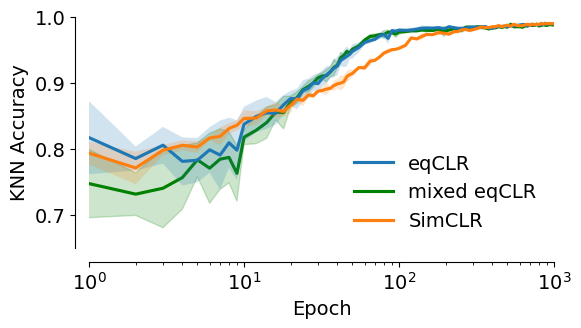

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
font = 14

# x values
x = np.array(list(blood_perf_mean_df.columns))

# eqCLR
y_eq = np.array(list(blood_perf_mean['eqResNet_N=4'].values()))
std_eq = np.array(list(blood_perf_std['eqResNet_N=4'].values()))

ax.plot(
    x,
    y_eq,
    '-',
    label='eqCLR',
    linewidth=2.25
)

ax.fill_between(
    x,
    y_eq - std_eq,
    y_eq + std_eq,
    alpha=0.2
)

# mixed_eqResNet_N=4
y_eq_mixed = np.array(list(blood_perf_mean['mixed_eqResNet_N=4'].values()))
std_eq_mixed = np.array(list(blood_perf_std['mixed_eqResNet_N=4'].values()))

ax.plot(
    x,
    y_eq_mixed,
    '-',
    label='mixed eqCLR',
    linewidth=2.25,
    color='green',
    zorder=-1
)

ax.fill_between(
    x,
    y_eq_mixed - std_eq_mixed,
    y_eq_mixed + std_eq_mixed,
    alpha=0.2,
    color='green',
    zorder=-1,
)

# SimCLR
y_sim = np.array(list(blood_perf_mean['ResNet18'].values()))
std_sim = np.array(list(blood_perf_std['ResNet18'].values()))

ax.plot(
    x,
    y_sim,
    '-',
    label='SimCLR',
    linewidth=2.25
)

ax.fill_between(
    x,
    y_sim - std_sim,
    y_sim + std_sim,
    alpha=0.2
)

ax.set_xscale('log')
ax.set_xlim(1, 1000)   # log-scale cannot include 0
ax.set_ylim(0.65, 1.0)

ax.spines['bottom'].set_position(('outward', 10))
ax.spines['left'].set_position(('outward', 10))

ax.set_xlabel('Epoch', fontsize=font)
ax.set_ylabel('KNN Accuracy', fontsize=font)

ax.legend(fontsize=font, frameon=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.tick_params(axis='both', labelsize=font)

# save figure
# plt.savefig('figures/convergence_plot.pdf', bbox_inches='tight')

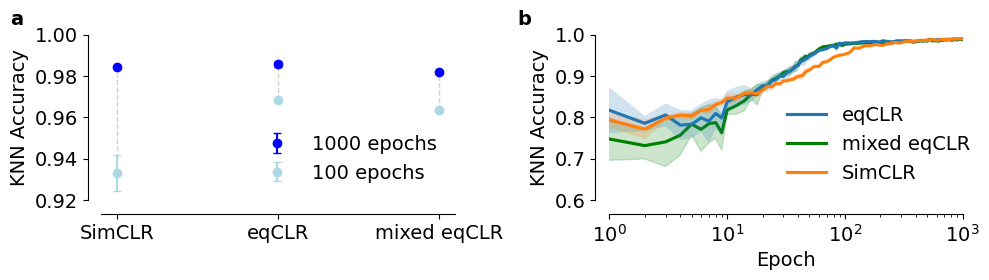

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
font = 14

# plot a absolute KNN
x = ['SimCLR', 'eqCLR', 'mixed eqCLR']
keys1000 = ['ResNet18', 'eqResNet_N=4', 'mixed_eqResNet_N=4']
keys100 = ['ResNet18_100', 'eqResNet_N=4_100', 'mixed_eqResNet_N=4_100']

for i, (key1000, key100) in enumerate(zip(keys1000, keys100)):

    y100 = blood_perf_1000[key100]['KNN']
    y1000 = blood_perf_1000[key1000]['KNN']

    err100 = blood_perf_1000[key100]['KNN_std']
    err1000 = blood_perf_1000[key1000]['KNN_std']

    # 1000 epochs
    ax[0].errorbar(
        x[i],
        y1000,
        yerr=err1000,
        fmt='o',
        color='blue',
        capsize=3,
        zorder=3,
        label='1000 epochs' if i == 0 else None
    )

    # connection
    ax[0].plot(
        [x[i], x[i]],
        [y100, y1000],
        color='lightgray',
        linewidth=1,
        zorder=1,
        linestyle='--'
    )

    # 100 epochs
    ax[0].errorbar(
        x[i],
        y100,
        yerr=err100,
        fmt='o',
        color='lightblue',
        capsize=3,
        zorder=3,
        label='100 epochs' if i == 0 else None,
        clip_on=False
    )    

ax[0].set_ylabel('KNN Accuracy', fontsize=font)
ax[0].tick_params(axis='both', labelsize=font)
ax[0].legend(fontsize=font, frameon=False)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].spines['bottom'].set_position(('outward', 10))
ax[0].spines['left'].set_position(('outward', 10))
ax[0].set_ylim(0.92, 1.0)
ax[0].set_yticks([0.92, 0.94, 0.96, 0.98, 1.0])

# x values
x = np.array(list(blood_perf_mean_df.columns))

# eqCLR
y_eq = np.array(list(blood_perf_mean['eqResNet_N=4'].values()))
std_eq = np.array(list(blood_perf_std['eqResNet_N=4'].values()))

ax[1].plot(
    x,
    y_eq,
    '-',
    label='eqCLR',
    linewidth=2.25
)

ax[1].fill_between(
    x,
    y_eq - std_eq,
    y_eq + std_eq,
    alpha=0.2
)

# mixed eqCLR
y_eq_mixed = np.array(list(blood_perf_mean['mixed_eqResNet_N=4'].values()))
std_eq_mixed = np.array(list(blood_perf_std['mixed_eqResNet_N=4'].values()))

ax[1].plot(
    x,
    y_eq_mixed,
    '-',
    label='mixed eqCLR',
    linewidth=2.25,
    color='green',
    zorder=-1
)

ax[1].fill_between(
    x,
    y_eq_mixed - std_eq_mixed,
    y_eq_mixed + std_eq_mixed,
    alpha=0.2,
    color='green',
    zorder=-1
)

# SimCLR
y_sim = np.array(list(blood_perf_mean['ResNet18'].values()))
std_sim = np.array(list(blood_perf_std['ResNet18'].values()))

ax[1].plot(
    x,
    y_sim,
    '-',
    label='SimCLR',
    linewidth=2.25
)

ax[1].fill_between(
    x,
    y_sim - std_sim,
    y_sim + std_sim,
    alpha=0.2
)

ax[1].set_xscale('log')
ax[1].set_xlim(1, 1000)   # log-scale cannot include 0
ax[1].set_ylim(0.6, 1.0)
#ax[1].set_yticks([0.75, 0.8, 0.85, 0.9, 0.95, 1.0])

ax[1].spines['bottom'].set_position(('outward', 10))
ax[1].spines['left'].set_position(('outward', 10))

ax[1].set_xlabel('Epoch', fontsize=font)
ax[1].set_ylabel('KNN Accuracy', fontsize=font)

ax[1].legend(fontsize=font, frameon=False, loc='lower right', bbox_to_anchor=(1.07, 0))

ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

ax[1].tick_params(axis='both', labelsize=font)

# labels a and b
ax[0].text(
    -0.22,
    1.15,
    'a',
    transform=ax[0].transAxes,
    fontsize=font,
    fontweight='bold',
    va='top',
    ha='right'
)

ax[1].text(
    -0.22,
    1.15,
    'b',
    transform=ax[1].transAxes,
    fontsize=font,
    fontweight='bold',
    va='top',
    ha='right'
)

plt.tight_layout()

# PathMNIST

In [9]:
path_perf_all = {}
path_perf_all_1000 = {}

# Resnet
path_perf_all['ResNet18'] = {}
path_perf_all_1000['ResNet18'] = {}
knns = []
for rs in range(3):
    eval_path = f'results_1000/pathmnist/model_eval/1001_seed{rs}_pathmnist_129-resnet18_1000epochs_eval.pkl'
    details_path = f'results_1000/pathmnist/model_details/1001_seed{rs}_pathmnist_129-resnet18_1000epochs_details.pkl'

    with open(eval_path, 'rb') as f:
        eval = pickle.load(f)

    with open(details_path, 'rb') as f:
        details = pickle.load(f)

    path_perf_all['ResNet18'][f'seed{rs}'] = details['KNN during training']
    knns.append(eval['euclidean'][10])

path_perf_all_1000['ResNet18']['KNN'] = np.mean(knns)
path_perf_all_1000['ResNet18']['KNN_std'] = np.std(knns)

# equivariant SimCLR
for n in [4]:
    path_perf_all[f'eqResNet_N={n}'] = {}
    path_perf_all_1000[f'eqResNet_N={n}'] = {}
    knns = []
    for rs in range(3):
        eval_path = f'results_1000/pathmnist/model_eval/0003_seed{rs}_pathmnist_129-eqCLR_resnet18_N{n}_rot_kp_1000epochs_lr0.06_eval.pkl'
        details_path = f'results_1000/pathmnist/model_details/0003_seed{rs}_pathmnist_129-eqCLR_resnet18_N{n}_rot_kp_1000epochs_lr0.06_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        path_perf_all[f'eqResNet_N={n}'][f'seed{rs}'] = details['KNN during training']
        knns.append(eval['euclidean'][10])
    
    path_perf_all_1000[f'eqResNet_N={n}']['KNN'] = np.mean(knns)
    path_perf_all_1000[f'eqResNet_N={n}']['KNN_std'] = np.std(knns)

# mixed equivariant SimCLR
for n in [4]:
    path_perf_all[f'mixed_eqResNet_N={n}'] = {}
    path_perf_all_1000[f'mixed_eqResNet_N={n}'] = {}
    knns = []
    for rs in range(3):
        eval_path = f'results_1000/pathmnist/model_eval/1004_seed{rs}_pathmnist_129-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_1000epochs_lr0.06_eval.pkl'
        details_path = f'results_1000/pathmnist/model_details/1004_seed{rs}_pathmnist_129-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_1000epochs_lr0.06_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        path_perf_all[f'mixed_eqResNet_N={n}'][f'seed{rs}'] = details['KNN during training']
        knns.append(eval['euclidean'][10])
    path_perf_all_1000[f'mixed_eqResNet_N={n}']['KNN'] = np.mean(knns)
    path_perf_all_1000[f'mixed_eqResNet_N={n}']['KNN_std'] = np.std(knns)

path_perf_all_1000['ResNet18_100'] = {'KNN': 0.938579, 'KNN_std': 0.002447}
path_perf_all_1000['eqResNet_N=4_100'] = {'KNN': 0.937976, 'KNN_std': 0.003316}
path_perf_all_1000['mixed_eqResNet_N=4_100'] = {'KNN': 0.928552, 'KNN_std': 0.001491}

In [10]:
path_perf_mean = {}
path_perf_std = {}

for model_name, seeds in path_perf_all.items():
    path_perf_mean[model_name] = {}
    path_perf_std[model_name] = {}

    eval_keys = next(iter(seeds.values())).keys()

    for eval_key in eval_keys:

        # Only use k=10 for euclidean/cosine
        if eval_key in ['euclidean', 'cosine']:

            values = [
                seeds[seed][eval_key][10]
                for seed in seeds
            ]

        # All other metrics are scalar
        else:
            values = [
                seeds[seed][eval_key]
                for seed in seeds
            ]

        path_perf_mean[model_name][eval_key] = float(np.mean(values))
        path_perf_std[model_name][eval_key] = float(np.std(values))
        
path_perf_mean_df = pd.DataFrame(path_perf_mean).T
display(path_perf_mean_df)

,0,1,2,3,4,5,6,7,8,9,...,775,800,825,850,875,900,925,950,975,999
ResNet18,0.750466,0.793249,0.809010,0.836565,0.849527,0.860023,0.875716,0.88278,0.896108,0.903805,...,0.994436,0.994869,0.993736,0.995935,0.995735,0.995668,0.996301,0.996135,0.996501,0.996635
eqResNet_N=4,0.764694,0.834933,0.872618,0.900440,0.921665,0.934293,0.944256,0.95042,0.953119,0.958916,...,0.993069,0.993769,0.994702,0.995169,0.995369,0.995402,0.996068,0.996268,0.996268,0.996135
mixed_eqResNet_N=4,0.769725,0.845628,0.877049,0.901273,0.920032,0.935926,0.941490,0.95052,0.955085,0.957684,...,0.993103,0.994436,0.994469,0.994769,0.995702,0.995868,0.995735,0.996401,0.996268,0.996301


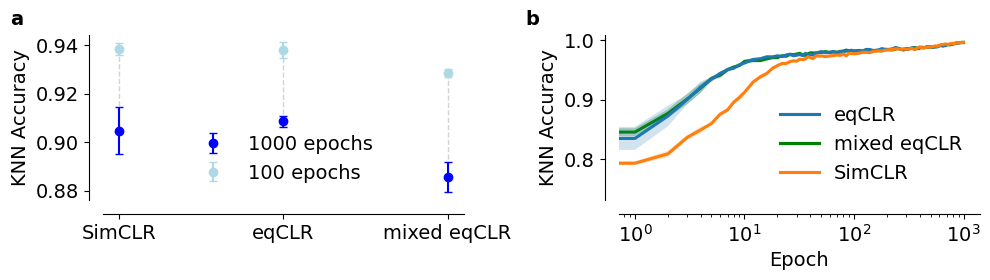

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
font = 14

# plot a absolute KNN
x = ['SimCLR', 'eqCLR', 'mixed eqCLR']
keys1000 = ['ResNet18', 'eqResNet_N=4', 'mixed_eqResNet_N=4']
keys100 = ['ResNet18_100', 'eqResNet_N=4_100', 'mixed_eqResNet_N=4_100']

for i, (key1000, key100) in enumerate(zip(keys1000, keys100)):

    y100 = path_perf_all_1000[key100]['KNN']
    y1000 = path_perf_all_1000[key1000]['KNN']

    err100 = path_perf_all_1000[key100]['KNN_std']
    err1000 = path_perf_all_1000[key1000]['KNN_std']

    # 1000 epochs
    ax[0].errorbar(
        x[i],
        y1000,
        yerr=err1000,
        fmt='o',
        color='blue',
        capsize=3,
        zorder=3,
        label='1000 epochs' if i == 0 else None
    )

    # connection
    ax[0].plot(
        [x[i], x[i]],
        [y100, y1000],
        color='lightgray',
        linewidth=1,
        zorder=1,
        linestyle='--'
    )

    # 100 epochs
    ax[0].errorbar(
        x[i],
        y100,
        yerr=err100,
        fmt='o',
        color='lightblue',
        capsize=3,
        zorder=3,
        label='100 epochs' if i == 0 else None,
        clip_on=False
    )      

ax[0].set_ylabel('KNN Accuracy', fontsize=font)
ax[0].tick_params(axis='both', labelsize=font)
ax[0].legend(fontsize=font, frameon=False)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].spines['bottom'].set_position(('outward', 10))
ax[0].spines['left'].set_position(('outward', 10))
# ax[0].set_ylim(0.92, 1.0)
# ax[0].set_yticks([0.92, 0.94, 0.96, 0.98, 1.0])

# x values
x = np.array(list(path_perf_mean_df.columns))

# eqCLR
y_eq = np.array(list(path_perf_mean['eqResNet_N=4'].values()))
std_eq = np.array(list(path_perf_std['eqResNet_N=4'].values()))

ax[1].plot(
    x,
    y_eq,
    '-',
    label='eqCLR',
    linewidth=2.25
)

ax[1].fill_between(
    x,
    y_eq - std_eq,
    y_eq + std_eq,
    alpha=0.2
)

# mixed eqCLR
y_eq_mixed = np.array(list(path_perf_mean['mixed_eqResNet_N=4'].values()))
std_eq_mixed = np.array(list(path_perf_std['mixed_eqResNet_N=4'].values()))

ax[1].plot(
    x,
    y_eq_mixed,
    '-',
    label='mixed eqCLR',
    linewidth=2.25,
    color='green',
    zorder=-1
)

ax[1].fill_between(
    x,
    y_eq_mixed - std_eq_mixed,
    y_eq_mixed + std_eq_mixed,
    alpha=0.2,
    color='green',
    zorder=-1
)

# SimCLR
y_sim = np.array(list(path_perf_mean['ResNet18'].values()))
std_sim = np.array(list(path_perf_std['ResNet18'].values()))

ax[1].plot(
    x,
    y_sim,
    '-',
    label='SimCLR',
    linewidth=2.25
)

ax[1].fill_between(
    x,
    y_sim - std_sim,
    y_sim + std_sim,
    alpha=0.2
)

ax[1].set_xscale('log')
# ax[1].set_xlim(1, 1000)   # log-scale cannot include 0
# ax[1].set_ylim(0.75, 1.0)
# ax[1].set_yticks([0.75, 0.8, 0.85, 0.9, 0.95, 1.0])

ax[1].spines['bottom'].set_position(('outward', 10))
ax[1].spines['left'].set_position(('outward', 10))

ax[1].set_xlabel('Epoch', fontsize=font)
ax[1].set_ylabel('KNN Accuracy', fontsize=font)

ax[1].legend(fontsize=font, frameon=False)

ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

ax[1].tick_params(axis='both', labelsize=font)

# labels a and b
ax[0].text(
    -0.22,
    1.15,
    'a',
    transform=ax[0].transAxes,
    fontsize=font,
    fontweight='bold',
    va='top',
    ha='right'
)

ax[1].text(
    -0.22,
    1.15,
    'b',
    transform=ax[1].transAxes,
    fontsize=font,
    fontweight='bold',
    va='top',
    ha='right'
)

plt.tight_layout()
# save figure


# DermaMNIST

In [13]:
derma_perf_all = {}
derma_perf_all_1000 = {}

derma_perf_all['ResNet18'] = {}
derma_perf_all_1000['ResNet18'] = {}
knns = []
# Resnet
for rs in range(3):
    eval_path = f'results_1000/dermamnist/model_eval/1001_seed{rs}_resnet18_dermamnist_128_1000epochs_eval.pkl'
    details_path = f'results_1000/dermamnist/model_details/1001_seed{rs}_resnet18_dermamnist_128_1000epochs_details.pkl'

    with open(eval_path, 'rb') as f:
        eval = pickle.load(f)

    with open(details_path, 'rb') as f:
        details = pickle.load(f)

    derma_perf_all['ResNet18'][f'seed{rs}'] = details['KNN during training']
    knns.append(eval['euclidean'][10])

derma_perf_all_1000['ResNet18']['KNN'] = np.mean(knns)
derma_perf_all_1000['ResNet18']['KNN_std'] = np.std(knns)

# equivariant SimCLR
for n in [4]:
    derma_perf_all[f'eqResNet_N={n}'] = {}
    derma_perf_all_1000[f'eqResNet_N={n}'] = {}
    knns = []
    for rs in range(2):
        eval_path = f'results_1000/dermamnist/model_eval/0001_seed{rs}_dermamnist_129-eqCLR_resnet18_N{n}_rot_kp_1000epochs_eval.pkl'
        details_path = f'results_1000/dermamnist/model_details/0001_seed{rs}_dermamnist_129-eqCLR_resnet18_N{n}_rot_kp_1000epochs_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        derma_perf_all[f'eqResNet_N={n}'][f'seed{rs}'] = details['KNN during training']
        knns.append(eval['euclidean'][10])
    derma_perf_all_1000[f'eqResNet_N={n}']['KNN'] = np.mean(knns)
    derma_perf_all_1000[f'eqResNet_N={n}']['KNN_std'] = np.std(knns)

# mixed equivariant SimCLR
for n in [4]:
    derma_perf_all[f'mixed_eqResNet_N={n}'] = {}
    derma_perf_all_1000[f'mixed_eqResNet_N={n}'] = {}
    knns = []
    for rs in range(3):
        eval_path = f'results_1000/dermamnist/model_eval/0002_seed{rs}_dermamnist_129-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_1000epochs_eval.pkl'
        details_path = f'results_1000/dermamnist/model_details/0002_seed{rs}_dermamnist_129-mixed_eqCLR_resnet18_2eqblocks_N{n}_rot_kp_1000epochs_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        derma_perf_all[f'mixed_eqResNet_N={n}'][f'seed{rs}'] = details['KNN during training']
        knns.append(eval['euclidean'][10])
    derma_perf_all_1000[f'mixed_eqResNet_N={n}']['KNN'] = np.mean(knns)
    derma_perf_all_1000[f'mixed_eqResNet_N={n}']['KNN_std'] = np.std(knns)

derma_perf_all_1000['ResNet18_100'] = {'KNN': 0.718537, 'KNN_std': 0.002050}
derma_perf_all_1000['eqResNet_N=4_100'] = {'KNN': 0.733832, 'KNN_std': 0.004858}
derma_perf_all_1000['mixed_eqResNet_N=4_100'] = {'KNN': 0.733001, 'KNN_std': 0.001695}

In [14]:
derma_perf_mean = {}
derma_perf_std = {}

for model_name, seeds in derma_perf_all.items():
    derma_perf_mean[model_name] = {}
    derma_perf_std[model_name] = {}

    eval_keys = next(iter(seeds.values())).keys()

    for eval_key in eval_keys:

        # All other metrics are scalar
        values = [
            seeds[seed][eval_key]
            for seed in seeds
        ]

        derma_perf_mean[model_name][eval_key] = float(np.mean(values))
        derma_perf_std[model_name][eval_key] = float(np.std(values))
        
derma_perf_mean_df = pd.DataFrame(derma_perf_mean).T
display(derma_perf_mean_df)

,0,1,2,3,4,5,6,7,8,9,...,775,800,825,850,875,900,925,950,975,999
ResNet18,0.690263,0.681289,0.689266,0.698239,0.703556,0.706547,0.710535,0.716517,0.703224,0.715188,...,0.764706,0.767032,0.765703,0.771353,0.771353,0.770688,0.769691,0.770023,0.770356,0.770023
eqResNet_N=4,0.668495,0.664506,0.679960,0.699402,0.713858,0.718345,0.725823,0.714855,0.712363,0.721834,...,0.773180,0.769192,0.777168,0.770189,0.771685,0.777667,0.773180,0.772682,0.776171,0.773679
mixed_eqResNet_N=4,0.665670,0.659355,0.677301,0.691592,0.704885,0.702891,0.707212,0.713194,0.706547,0.716517,...,0.774676,0.763709,0.767365,0.768694,0.767365,0.767365,0.760718,0.767032,0.767365,0.766035


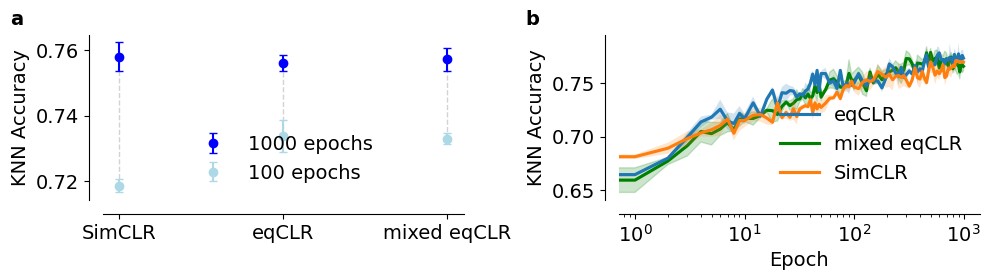

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
font = 14

# plot a absolute KNN
x = ['SimCLR', 'eqCLR', 'mixed eqCLR']
keys1000 = ['ResNet18', 'eqResNet_N=4', 'mixed_eqResNet_N=4']
keys100 = ['ResNet18_100', 'eqResNet_N=4_100', 'mixed_eqResNet_N=4_100']

for i, (key1000, key100) in enumerate(zip(keys1000, keys100)):

    y100 = derma_perf_all_1000[key100]['KNN']
    y1000 = derma_perf_all_1000[key1000]['KNN']

    err100 = derma_perf_all_1000[key100]['KNN_std']
    err1000 = derma_perf_all_1000[key1000]['KNN_std']

    # 1000 epochs
    ax[0].errorbar(
        x[i],
        y1000,
        yerr=err1000,
        fmt='o',
        color='blue',
        capsize=3,
        zorder=3,
        label='1000 epochs' if i == 0 else None
    )

    # connection
    ax[0].plot(
        [x[i], x[i]],
        [y100, y1000],
        color='lightgray',
        linewidth=1,
        zorder=1,
        linestyle='--'
    )

    # 100 epochs
    ax[0].errorbar(
        x[i],
        y100,
        yerr=err100,
        fmt='o',
        color='lightblue',
        capsize=3,
        zorder=3,
        label='100 epochs' if i == 0 else None,
        clip_on=False
    )

ax[0].set_ylabel('KNN Accuracy', fontsize=font)
ax[0].tick_params(axis='both', labelsize=font)
ax[0].legend(fontsize=font, frameon=False)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].spines['bottom'].set_position(('outward', 10))
ax[0].spines['left'].set_position(('outward', 10))
# ax[0].set_ylim(0.92, 1.0)
# ax[0].set_yticks([0.92, 0.94, 0.96, 0.98, 1.0])

# x values
x = np.array(list(derma_perf_mean_df.columns))

# eqCLR
y_eq = np.array(list(derma_perf_mean['eqResNet_N=4'].values()))
std_eq = np.array(list(derma_perf_std['eqResNet_N=4'].values()))

ax[1].plot(
    x,
    y_eq,
    '-',
    label='eqCLR',
    linewidth=2.25
)

ax[1].fill_between(
    x,
    y_eq - std_eq,
    y_eq + std_eq,
    alpha=0.2
)

# mixed eqCLR
y_eq_mixed = np.array(list(derma_perf_mean['mixed_eqResNet_N=4'].values()))
std_eq_mixed = np.array(list(derma_perf_std['mixed_eqResNet_N=4'].values()))

ax[1].plot(
    x,
    y_eq_mixed,
    '-',
    label='mixed eqCLR',
    linewidth=2.25,
    color='green',
    zorder=-1
)

ax[1].fill_between(
    x,
    y_eq_mixed - std_eq_mixed,
    y_eq_mixed + std_eq_mixed,
    alpha=0.2,
    color='green',
    zorder=-1
)


# SimCLR
y_sim = np.array(list(derma_perf_mean['ResNet18'].values()))
std_sim = np.array(list(derma_perf_std['ResNet18'].values()))

ax[1].plot(
    x,
    y_sim,
    '-',
    label='SimCLR',
    linewidth=2.25
)

ax[1].fill_between(
    x,
    y_sim - std_sim,
    y_sim + std_sim,
    alpha=0.2
)

ax[1].set_xscale('log')
# ax[1].set_xlim(1, 1000)   # log-scale cannot include 0
# ax[1].set_ylim(0.75, 1.0)
# ax[1].set_yticks([0.75, 0.8, 0.85, 0.9, 0.95, 1.0])

ax[1].spines['bottom'].set_position(('outward', 10))
ax[1].spines['left'].set_position(('outward', 10))

ax[1].set_xlabel('Epoch', fontsize=font)
ax[1].set_ylabel('KNN Accuracy', fontsize=font)

ax[1].legend(fontsize=font, frameon=False)

ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

ax[1].tick_params(axis='both', labelsize=font)

# labels a and b
ax[0].text(
    -0.22,
    1.15,
    'a',
    transform=ax[0].transAxes,
    fontsize=font,
    fontweight='bold',
    va='top',
    ha='right'
)

ax[1].text(
    -0.22,
    1.15,
    'b',
    transform=ax[1].transAxes,
    fontsize=font,
    fontweight='bold',
    va='top',
    ha='right'
)

plt.tight_layout()
# save figure


# Cifar10

In [16]:
cifar_perf_all = {}
cifar_perf1000  = {}

# Resnet
cifar_perf_all['ResNet18'] = {}
cifar_perf1000['ResNet18'] = {}
knns = []
for rs in [0, 2]:
    eval_path = f'results_1000/cifar10/model_eval/C-1001_seed{rs}_cifar10_32_no_resize_no_maxpool-resnet18_1000epochs_eval.pkl'
    details_path = f'results_1000/cifar10/model_details/C-1001_seed{rs}_cifar10_32_no_resize_no_maxpool-resnet18_1000epochs_details.pkl'

    with open(eval_path, 'rb') as f:
        eval = pickle.load(f)

    with open(details_path, 'rb') as f:
        details = pickle.load(f)

    cifar_perf_all['ResNet18'][f'seed{rs}'] = details['KNN during training']
    knns.append(eval['euclidean'][10])
cifar_perf1000['ResNet18']['KNN'] = np.mean(knns)
cifar_perf1000['ResNet18']['KNN_std'] = np.std(knns)

# equivariant SimCLR
for n in [2]:
    cifar_perf_all[f'eqResNet_N={n}'] = {}
    cifar_perf1000[f'eqResNet_N={n}'] = {}
    knns = []
    for rs in range(3):
        eval_path = f'results_1000/cifar10/model_eval/C-0003_seed{rs}_cifar10-eqCLR_resnet18_N2_no_maxpool_flip_rot_kp_1000epochs_lr0.06_eval.pkl'
        details_path = f'results_1000/cifar10/model_details/C-0003_seed{rs}_cifar10-eqCLR_resnet18_N2_no_maxpool_flip_rot_kp_1000epochs_lr0.06_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        cifar_perf_all[f'eqResNet_N={n}'][f'seed{rs}'] = details['KNN during training']
        knns.append(eval['euclidean'][10])
    cifar_perf1000[f'eqResNet_N={n}']['KNN'] = np.mean(knns)
    cifar_perf1000[f'eqResNet_N={n}']['KNN_std'] = np.std(knns)

# mixed equivariant SimCLR
for n in [2]:
    cifar_perf_all[f'mixed_eqResNet_N={n}'] = {}
    cifar_perf1000[f'mixed_eqResNet_N={n}'] = {}
    knns = []
    for rs in range(3):
        eval_path = f'results_1000/cifar10/model_eval/C-0003_seed{rs}_cifar10-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_1000epochs_lr0.06_eval.pkl'
        details_path = f'results_1000/cifar10/model_details/C-0003_seed{rs}_cifar10-mixed_eqCLR_resnet18_2eqblocks_N{n}_flip_rot_kp_1000epochs_lr0.06_details.pkl'

        with open(eval_path, 'rb') as f:
            eval = pickle.load(f)

        with open(details_path, 'rb') as f:
            details = pickle.load(f)

        cifar_perf_all[f'mixed_eqResNet_N={n}'][f'seed{rs}'] = details['KNN during training']
        knns.append(eval['euclidean'][10])
    cifar_perf1000[f'mixed_eqResNet_N={n}']['KNN'] = np.mean(knns)
    cifar_perf1000[f'mixed_eqResNet_N={n}']['KNN_std'] = np.std(knns)

cifar_perf1000['ResNet18_100'] = {'KNN': 0.822067, 'KNN_std': 0.001014}
cifar_perf1000['eqResNet_N=2_100'] = {'KNN': 0.853000, 'KNN_std': 0.002499}
cifar_perf1000['mixed_eqResNet_N=2_100'] = {'KNN': 0.831000, 'KNN_std': 0.001100}


In [17]:
cifar_perf_mean = {}
cifar_perf_std = {}

for model_name, seeds in cifar_perf_all.items():
    cifar_perf_mean[model_name] = {}
    cifar_perf_std[model_name] = {}

    eval_keys = next(iter(seeds.values())).keys()

    for eval_key in eval_keys:

        # All other metrics are scalar
        values = [
            seeds[seed][eval_key]
            for seed in seeds
        ]

        cifar_perf_mean[model_name][eval_key] = float(np.mean(values))
        cifar_perf_std[model_name][eval_key] = float(np.std(values))
        
cifar_perf_mean_df = pd.DataFrame(cifar_perf_mean).T
display(cifar_perf_mean_df)

,0,1,2,3,4,5,6,7,8,9,...,775,800,825,850,875,900,925,950,975,999
ResNet18,0.426950,0.454700,0.469300,0.479300,0.489900,0.518700,0.530050,0.54325,0.556900,0.566700,...,0.894650,0.894450,0.896900,0.897800,0.895100,0.8946,0.895300,0.895050,0.894500,0.89395
eqResNet_N=2,0.371800,0.414667,0.450900,0.482467,0.525833,0.556167,0.580033,0.60050,0.624267,0.642933,...,0.899800,0.905100,0.905667,0.907033,0.905567,0.9048,0.905167,0.904300,0.903667,0.90470
mixed_eqResNet_N=2,0.368067,0.405167,0.441533,0.485233,0.525167,0.550833,0.571500,0.59210,0.611400,0.622733,...,0.886967,0.889567,0.892567,0.893933,0.893067,0.8960,0.895967,0.894333,0.894400,0.89470


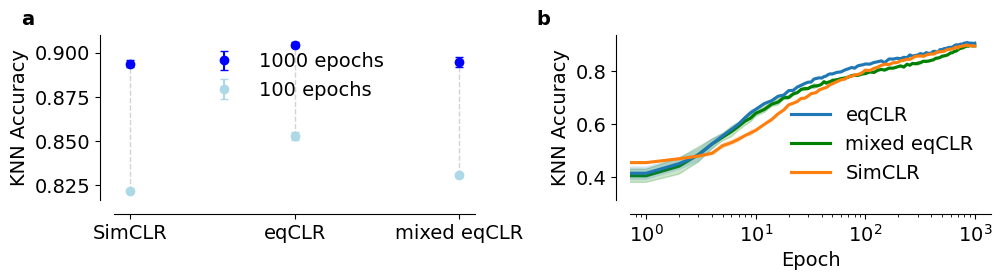

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
font = 14

# plot a absolute KNN
x = ['SimCLR', 'eqCLR', 'mixed eqCLR']
keys1000 = ['ResNet18', 'eqResNet_N=2', 'mixed_eqResNet_N=2']
keys100 = ['ResNet18_100', 'eqResNet_N=2_100', 'mixed_eqResNet_N=2_100']

for i, (key1000, key100) in enumerate(zip(keys1000, keys100)):

    y100 = cifar_perf1000[key100]['KNN']
    y1000 = cifar_perf1000[key1000]['KNN']

    err100 = cifar_perf1000[key100]['KNN_std']
    err1000 = cifar_perf1000[key1000]['KNN_std']

    # 1000 epochs
    ax[0].errorbar(
        x[i],
        y1000,
        yerr=err1000,
        fmt='o',
        color='blue',
        capsize=3,
        zorder=3,
        label='1000 epochs' if i == 0 else None
    )

    # connection
    ax[0].plot(
        [x[i], x[i]],
        [y100, y1000],
        color='lightgray',
        linewidth=1,
        zorder=1,
        linestyle='--'
    )

    # 100 epochs
    ax[0].errorbar(
        x[i],
        y100,
        yerr=err100,
        fmt='o',
        color='lightblue',
        capsize=3,
        zorder=3,
        label='100 epochs' if i == 0 else None,
        clip_on=False
    )     

ax[0].set_ylabel('KNN Accuracy', fontsize=font)
ax[0].tick_params(axis='both', labelsize=font)
ax[0].legend(fontsize=font, frameon=False)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].spines['bottom'].set_position(('outward', 10))
ax[0].spines['left'].set_position(('outward', 10))
# ax[0].set_ylim(0.92, 1.0)
# ax[0].set_yticks([0.92, 0.94, 0.96, 0.98, 1.0])

# x values
x = np.array(list(derma_perf_mean_df.columns))

# eqCLR
y_eq = np.array(list(cifar_perf_mean['eqResNet_N=2'].values()))
std_eq = np.array(list(cifar_perf_std['eqResNet_N=2'].values()))

ax[1].plot(
    x,
    y_eq,
    '-',
    label='eqCLR',
    linewidth=2.25
)

ax[1].fill_between(
    x,
    y_eq - std_eq,
    y_eq + std_eq,
    alpha=0.2
)

# mixed eqCLR
y_eq_mixed = np.array(list(cifar_perf_mean['mixed_eqResNet_N=2'].values()))
std_eq_mixed = np.array(list(cifar_perf_std['mixed_eqResNet_N=2'].values()))

ax[1].plot(
    x,
    y_eq_mixed,
    '-',
    label='mixed eqCLR',
    linewidth=2.25,
    color='green',
    zorder=-1
)

ax[1].fill_between(
    x,
    y_eq_mixed - std_eq_mixed,
    y_eq_mixed + std_eq_mixed,
    alpha=0.2,
    color='green',
    zorder=-1
)

# SimCLR
y_sim = np.array(list(cifar_perf_mean['ResNet18'].values()))
std_sim = np.array(list(cifar_perf_std['ResNet18'].values()))

ax[1].plot(
    x,
    y_sim,
    '-',
    label='SimCLR',
    linewidth=2.25
)

ax[1].fill_between(
    x,
    y_sim - std_sim,
    y_sim + std_sim,
    alpha=0.2
)

ax[1].set_xscale('log')
# ax[1].set_xlim(1, 1000)   # log-scale cannot include 0
# ax[1].set_ylim(0.75, 1.0)
# ax[1].set_yticks([0.75, 0.8, 0.85, 0.9, 0.95, 1.0])

ax[1].spines['bottom'].set_position(('outward', 10))
ax[1].spines['left'].set_position(('outward', 10))

ax[1].set_xlabel('Epoch', fontsize=font)
ax[1].set_ylabel('KNN Accuracy', fontsize=font)

ax[1].legend(fontsize=font, frameon=False)

ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

ax[1].tick_params(axis='both', labelsize=font)

# labels a and b
ax[0].text(
    -0.22,
    1.15,
    'a',
    transform=ax[0].transAxes,
    fontsize=font,
    fontweight='bold',
    va='top',
    ha='right'
)

ax[1].text(
    -0.22,
    1.15,
    'b',
    transform=ax[1].transAxes,
    fontsize=font,
    fontweight='bold',
    va='top',
    ha='right'
)

plt.tight_layout()
# save figure


# combined

In [19]:
knn_train = {
    'BloodMNIST': blood_perf_mean,
    'PathMNIST': path_perf_mean,
    'DermaMNIST': derma_perf_mean,
    'CIFAR10': cifar_perf_mean
}
knn_train_std = {
    'BloodMNIST': blood_perf_std,
    'PathMNIST': path_perf_std,
    'DermaMNIST': derma_perf_std,
    'CIFAR10': cifar_perf_std
}
perf_all = {
    'BloodMNIST': blood_perf_1000,
    'PathMNIST': path_perf_all_1000,
    'DermaMNIST': derma_perf_all_1000,
    'CIFAR10': cifar_perf1000
}

x_epochs = np.array(list(knn_train['BloodMNIST']['ResNet18'].keys()))

/scratch_local/bep071-2585396/tmp/ipykernel_3150668/1981281296.py:166: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


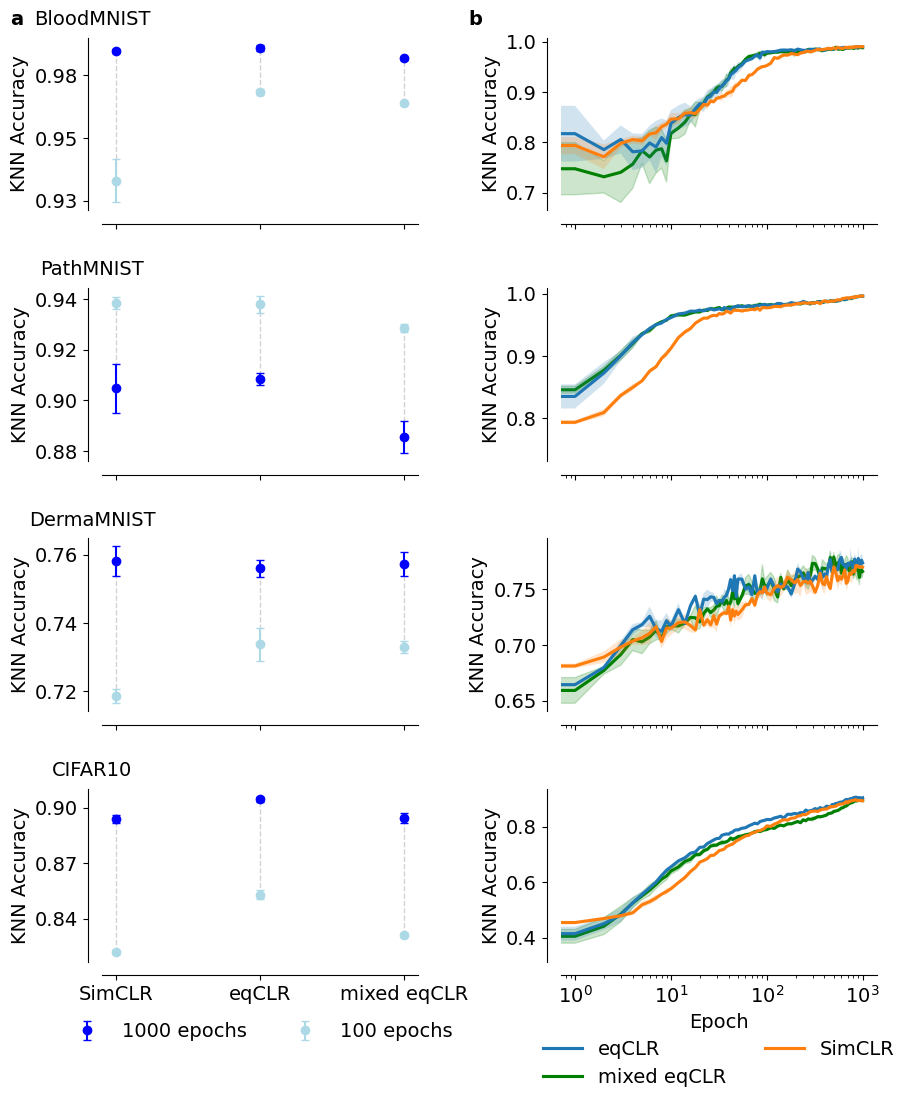

In [21]:
fig, ax = plt.subplots(4, 2, figsize=(10, 12), sharex='col', gridspec_kw={'hspace': 0.45, 'wspace': 0.45})

font = 14

x = ['SimCLR', 'eqCLR', 'mixed eqCLR']
keys1000 = ['ResNet18', 'eqResNet_N=4', 'mixed_eqResNet_N=4']
keys100 = ['ResNet18_100', 'eqResNet_N=4_100', 'mixed_eqResNet_N=4_100']

keys1000_cifar = ['ResNet18', 'eqResNet_N=2', 'mixed_eqResNet_N=2']
keys100_cifar = ['ResNet18_100', 'eqResNet_N=2_100', 'mixed_eqResNet_N=2_100']

for i, dataset in enumerate(['BloodMNIST', 'PathMNIST', 'DermaMNIST', 'CIFAR10']):

    if dataset == 'CIFAR10':
        keys1000 = keys1000_cifar
        keys100 = keys100_cifar
    
    knn_during_train = knn_train[dataset]
    knn_during_train_std = knn_train_std[dataset]

    for j, (key1000, key100) in enumerate(zip(keys1000, keys100)):

        if j == 0:
            ax[i, j].text(-0.03, 1.05, dataset, transform=ax[i, j].transAxes, ha='center', va='bottom', fontsize=font)

        y100 = perf_all[dataset][key100]['KNN']
        y1000 = perf_all[dataset][key1000]['KNN']

        err100 = perf_all[dataset][key100]['KNN_std']
        err1000 = perf_all[dataset][key1000]['KNN_std']

        # 1000 epochs
        ax[i, 0].errorbar(
            x[j],
            y1000,
            yerr=err1000,
            fmt='o',
            color='blue',
            capsize=3,
            zorder=3,
            label='1000 epochs' if j == 0 else None
        )

        # connection
        ax[i, 0].plot(
            [x[j], x[j]],
            [y100, y1000],
            color='lightgray',
            linewidth=1,
            zorder=1,
            linestyle='--'
        )

        # 100 epochs
        ax[i, 0].errorbar(
            x[j],
            y100,
            yerr=err100,
            fmt='o',
            color='lightblue',
            capsize=3,
            zorder=3,
            label='100 epochs' if j == 0 else None,
            clip_on=False
        )      

    ax[i, 0].set_ylabel('KNN Accuracy', fontsize=font)
    ax[i, 0].tick_params(axis='both', labelsize=font)
    # ax[i, 0].legend(fontsize=font, frameon=False)
    ax[i, 0].spines['top'].set_visible(False)
    ax[i, 0].spines['right'].set_visible(False)
    ax[i, 0].spines['bottom'].set_position(('outward', 10))
    ax[i, 0].spines['left'].set_position(('outward', 10))
    # ax[0].set_ylim(0.92, 1.0)
    # ax[0].set_yticks([0.92, 0.94, 0.96, 0.98, 1.0])

    # plot b KNN during training

    # eqCLR
    if dataset == 'CIFAR10':
        N = 2
    else:
        N = 4

    y_eq = np.array(list(knn_train[dataset][f'eqResNet_N={N}'].values()))
    std_eq = np.array(list(knn_train_std[dataset][f'eqResNet_N={N}'].values()))

    ax[i, 1].plot(
        x_epochs,
        y_eq,
        '-',
        label='eqCLR',
        linewidth=2.25
    )

    ax[i, 1].fill_between(
        x_epochs,
        y_eq - std_eq,
        y_eq + std_eq,
        alpha=0.2
    )

    # mixed eqCLR
    y_eq_mixed = np.array(list(knn_train[dataset][f'mixed_eqResNet_N={N}'].values()))
    std_eq_mixed = np.array(list(knn_train_std[dataset][f'mixed_eqResNet_N={N}'].values()))

    ax[i, 1].plot(
        x_epochs,
        y_eq_mixed,
        '-',
        label='mixed eqCLR',
        linewidth=2.25,
        color='green',
        zorder=-1
    )

    ax[i, 1].fill_between(
        x_epochs,
        y_eq_mixed - std_eq_mixed,
        y_eq_mixed + std_eq_mixed,
        alpha=0.2,
        color='green',
        zorder=-1
    )


    # SimCLR
    y_sim = np.array(list(knn_train[dataset]['ResNet18'].values()))
    std_sim = np.array(list(knn_train_std[dataset]['ResNet18'].values()))

    ax[i, 1].plot(
        x_epochs,
        y_sim,
        '-',
        label='SimCLR',
        linewidth=2.25
    )

    ax[i, 1].fill_between(
        x_epochs,
        y_sim - std_sim,
        y_sim + std_sim,
        alpha=0.2
    )

    ax[i, 1].set_xscale('log')

    ax[i, 1].spines['bottom'].set_position(('outward', 10))
    ax[i, 1].spines['left'].set_position(('outward', 10))

    ax[i, 1].set_ylabel('KNN Accuracy', fontsize=font)

    ax[i, 1].spines['top'].set_visible(False)
    ax[i, 1].spines['right'].set_visible(False)

    ax[i, 1].tick_params(axis='both', labelsize=font)

ax[-1, 1].set_xlabel('Epoch', fontsize=font)
# column label a and b
ax[0, 0].text(-0.27, 1.05, 'a', transform=ax[0, 0].transAxes, ha='center', va='bottom', fontsize=font, fontweight='bold')
ax[0, 1].text(-0.27, 1.05, 'b', transform=ax[0, 1].transAxes, ha='center', va='bottom', fontsize=font, fontweight='bold')


ax[3, 0].legend(fontsize=font, frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2)
ax[3, 1].legend(fontsize=font, frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.35), ncol=2)
plt.tight_layout()

for i in range(4):
    ax[i, 0].yaxis.set_major_locator(MaxNLocator(nbins=3, min_n_ticks=3))
    ax[i, 0].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

